# Python NLP Notebook

This is where I write my explanations

In [2]:
import spacy

In [3]:
nlp = spacy.load('en_core_web_lg')

In [5]:
with open('austen-corpus/northanger-abbey.txt', encoding='utf-8') as na:
    na_text = na.read()

In [6]:
import re

def clean_gutenberg_text(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    start_pattern = r"\*\*\*\s*START OF.*?\*\*\*"
    end_pattern = r"\*\*\*\s*END OF.*?\*\*\*"

    start_match = re.search(start_pattern, text, re.DOTALL | re.IGNORECASE)
    end_match = re.search(end_pattern, text, re.DOTALL | re.IGNORECASE)

    if not start_match or not end_match:
        raise ValueError("Could not locate Gutenberg boundaries.")

    cleaned = text[start_match.end():end_match.start()]

    return cleaned.strip()

In [8]:
clean_na_text = clean_gutenberg_text('austen-corpus/northanger-abbey.txt')

In [20]:
print(clean_na_text[0:2000])

Northanger Abbey


by Jane Austen

(1803)




Contents


 ADVERTISEMENT BY THE AUTHORESS, TO NORTHANGER ABBEY

 CHAPTER 1
 CHAPTER 2
 CHAPTER 3
 CHAPTER 4
 CHAPTER 5
 CHAPTER 6
 CHAPTER 7
 CHAPTER 8
 CHAPTER 9
 CHAPTER 10
 CHAPTER 11
 CHAPTER 12
 CHAPTER 13
 CHAPTER 14
 CHAPTER 15
 CHAPTER 16
 CHAPTER 17
 CHAPTER 18
 CHAPTER 19
 CHAPTER 20
 CHAPTER 21
 CHAPTER 22
 CHAPTER 23
 CHAPTER 24
 CHAPTER 25
 CHAPTER 26
 CHAPTER 27
 CHAPTER 28
 CHAPTER 29
 CHAPTER 30
 CHAPTER 31

 A NOTE ON THE TEXT




ADVERTISEMENT BY THE AUTHORESS, TO NORTHANGER ABBEY


This little work was finished in the year 1803, and intended for
immediate publication. It was disposed of to a bookseller, it was even
advertised, and why the business proceeded no farther, the author has
never been able to learn. That any bookseller should think it
worth-while to purchase what he did not think it worth-while to publish
seems extraordinary. But with this, neither the author nor the public
have any other concern than as some o

In [10]:
na_doc = nlp(clean_na_text)

In [14]:
sentences = list(na_doc.sents)

In [15]:
sentences[23]

Writing and accounts she was taught by her father; French
by her mother: her proficiency in either was not remarkable, and she
shirked her lessons in both whenever she could.

In [16]:
def show_ents(doc):
    if doc.ents:
        for ent in doc.ents:
            print(ent.text + ' - ' + ent.label_ + ' - ' + str(spacy.explain(ent.label_)))

In [19]:
female_characters = [
    "Catherine Morland",
    "Mrs. Morland",
    "Eleanor Tilney",
    "Isabella Thorpe",
    "Mrs. Allen",
    "Miss Tilney",
    "Mrs. Tilney",
    "Anne Radcliffe",
    "Miss Andrews",
    "Miss Thorpe",
    "Mrs. Thorpe",
    "Alice",
    "Lucy",
    "Sally",
    "Emily",
    "Maria",
    "Julia",
    "Leonora",
    "Matilda",
    "The Marchioness",
    "The Duchess",
    "The Countess",
    "Mrs. Hughes",
    "Mrs. Allen's Friend",
    "Old Allen's Housekeeper"
]

male_characters = [
    "Henry Tilney",
    "General Tilney",
    "Frederick Tilney",
    "James Morland",
    "Mr. Morland",
    "John Thorpe",
    "Mr. Allen",
    "Richard Morland",
    "George Morland",
    "Edward Morland",
    "William Morland",
    "Charles Morland",
    "Mr. Thorpe",
    "Captain Tilney",
    "Mr. King",
    "The Master of ceremonies",
    "Blaize Castle Caretaker",
    "Valancourt",
    "Montoni",
    "Rochefide",
    "St. Aubert",
    "Theodore",
    "Count Morcano",
    "Count De Courcy",
    "General La Motte",
    "The Marquis",
    "The Duke"
]

In [18]:
persons = list(set(ent.text.replace("\n", " ").strip() for ent in na_doc.ents if ent.label_ == "PERSON"))

In [17]:
show_ents(na_doc)

Northanger Abbey - PERSON - People, including fictional
Jane Austen - PERSON - People, including fictional
1803 - CARDINAL - Numerals that do not fall under another type
NORTHANGER ABBEY - PERSON - People, including fictional
CHAPTER 2
  - LAW - Named documents made into laws.
3 - CARDINAL - Numerals that do not fall under another type
CHAPTER 4
 CHAPTER 5 - LAW - Named documents made into laws.
6 - CARDINAL - Numerals that do not fall under another type
8 - CARDINAL - Numerals that do not fall under another type
9 - CARDINAL - Numerals that do not fall under another type
10 - CARDINAL - Numerals that do not fall under another type
11 - CARDINAL - Numerals that do not fall under another type
12 - CARDINAL - Numerals that do not fall under another type
13 - CARDINAL - Numerals that do not fall under another type
14 - CARDINAL - Numerals that do not fall under another type
15 - CARDINAL - Numerals that do not fall under another type
16 - CARDINAL - Numerals that do not fall under another

In [19]:
persons

['morland',
 'Robertson',
 'Woodston',
 'Northanger',
 'Tom Jones',
 'Courteney',
 'Maria',
 'Charlotte Davis',
 'Thorpe',
 'James',
 'Catherine',
 'John',
 'coquette',
 'Louisas',
 'Fletcher',
 'Mysterious Warnings',
 'Allens',
 'Laura Place',
 'Henry Tilney',
 'Henry',
 'Anne',
 'Sophia',
 'Blair',
 'Abbey',
 'Alfred the Great',
 'Mechlin',
 'Lansdown',
 'Eleanor',
 'Tower',
 'Richardson',
 'Isabella',
 'John Murray',
 'Tilney',
 'Anne Mitchell',
 'Drummond',
 'Frederick Tilney',
 'Hodges',
 'Wick Rocks',
 'Belinda',
 'Isabella Thorpe',
 'Richard',
 'Alice',
 'Julias',
 'John Thorpe’s',
 'Austen',
 'Charles Hodges',
 'Catherine Morland',
 'King',
 'Miss     Thorpe',
 'William',
 'Emily',
 'Miss Morland',
 'Andrews',
 'Radcliffe',
 'Skinner',
 'Skinners',
 'Miss Tilney',
 'James Morland’s',
 'Miss Anne',
 'Sally',
 'Mamma',
 'Sarah',
 'Papa',
 'Johnson',
 'Muslin',
 'Pope',
 'Catherine Morland’s',
 'Edgar',
 'Allen',
 'Eleanor Tilney',
 'Miss Thorpe',
 'Charles Grandison',
 'Valancour

In [27]:
female_characters = [
    # Morlands
    "Catherine Morland",
    "Catherine",
    "catherine",
    "Miss Morland",
    "Miss Morland’s",
    "Catherine Morland’s",
    "Mrs. Morland",
    "Mrs Morland",
    "Sarah",
    "Sally",
    
    # Tilneys
    "Eleanor Tilney",
    "Eleanor",
    "Miss Tilney",
    "Miss Anne",
    "Mrs. Tilney",
    "Mrs Tilney",
    
    # Thorpes
    "Isabella Thorpe",
    "Isabella",
    "isabella",
    "Miss Thorpe",
    "Miss     Thorpe",
    "Miss Thorpe’s",
    "Mrs. Thorpe",
    "Mrs Thorpe",
    
    # Allens
    "Mrs. Allen",
    "Mrs Allen",
    "Allens",
    
    # Other women in the novel / referenced women
    "Anne",
    "Anne Mitchell",
    "Alice",
    "Emily",
    "Sophia",
    "Maria",
    "Harriet",
    "Dorothy",
    "Charlotte Davis",
    "Miss Drummond",
    "a Miss Drummond",
    "Viscountess",
    "Belle",
    "Laura Place"
]

male_characters = [
    # Morlands
    "James Morland",
    "James",
    "james",
    "James Morland’s",
    "Mr. Morland",
    "Mr Morland",
    "Richard",
    "George",
    "William",
    
    # Tilneys
    "Henry Tilney",
    "Henry",
    "General Tilney",
    "Tilney",
    "Tilneys",
    "Frederick Tilney",
    "Frederick",
    "frederick",
    
    # Thorpes
    "John Thorpe",
    "John",
    "John Thorpe’s",
    "Thorpe",
    "thorpe",
    "Thorpes",
    "Mr. Thorpe",
    "Mr Thorpe",
    
    # Allens
    "Mr. Allen",
    "Mr Allen",
    "Allen",
    
    # Other men in the novel / referenced men
    "Charles Hodges",
    "Sam Fletcher",
    "Fletcher",
    "Hodges",
    "King",
    "Andrews",
    "Brown",
    "Freeman",
    "Hughes",
    "Robinson",
    "Smith",
    "Johnson",
    "Hunt",
    "Skinner",
    "Skinners",
    "George Parry",
    "Papa",
    
    # Literary/historical male references appearing in text
    "Alfred the Great",
    "Pope",
    "Richardson",
    "Shakespeare",
    "Sterne",
    "Hume",
    "Radcliffe",
    "Montoni",
    "Valancourt",
    "Edgar",
    "Jove",
    "Charles Grandison"
]

In [22]:
import re
from pathlib import Path

# Read the full text
with open("austen-corpus/northanger-abbey.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Split on chapter headings
chapter_pattern = r"\n\s*CHAPTER\s+(\d+)\s*\n"

parts = re.split(chapter_pattern, text, flags=re.IGNORECASE)

# Create output directory
output_dir = Path("northanger_abbey_chapters")
output_dir.mkdir(exist_ok=True)

# parts structure:
# [front_matter, chapter_num, chapter_text, chapter_num, chapter_text...]

for i in range(1, len(parts), 2):

    chapter_num = int(parts[i])
    chapter_text = parts[i + 1].strip()

    filename = f"northanger_abbey_ch_{chapter_num:02}.txt"

    filepath = output_dir / filename

    with open(filepath, "w", encoding="utf-8") as f:
        f.write(chapter_text)

    print(f"Wrote {filename}")

Wrote northanger_abbey_ch_01.txt
Wrote northanger_abbey_ch_03.txt
Wrote northanger_abbey_ch_05.txt
Wrote northanger_abbey_ch_07.txt
Wrote northanger_abbey_ch_09.txt
Wrote northanger_abbey_ch_11.txt
Wrote northanger_abbey_ch_13.txt
Wrote northanger_abbey_ch_15.txt
Wrote northanger_abbey_ch_17.txt
Wrote northanger_abbey_ch_19.txt
Wrote northanger_abbey_ch_21.txt
Wrote northanger_abbey_ch_23.txt
Wrote northanger_abbey_ch_25.txt
Wrote northanger_abbey_ch_27.txt
Wrote northanger_abbey_ch_29.txt
Wrote northanger_abbey_ch_31.txt
Wrote northanger_abbey_ch_01.txt
Wrote northanger_abbey_ch_02.txt
Wrote northanger_abbey_ch_03.txt
Wrote northanger_abbey_ch_04.txt
Wrote northanger_abbey_ch_05.txt
Wrote northanger_abbey_ch_06.txt
Wrote northanger_abbey_ch_07.txt
Wrote northanger_abbey_ch_08.txt
Wrote northanger_abbey_ch_09.txt
Wrote northanger_abbey_ch_10.txt
Wrote northanger_abbey_ch_11.txt
Wrote northanger_abbey_ch_12.txt
Wrote northanger_abbey_ch_13.txt
Wrote northanger_abbey_ch_14.txt
Wrote nort

In [26]:
import re
from pathlib import Path
import pandas as pd

def count_entities_by_chapter(chapter_dir, entity_groups):
    """
    Count occurrences of grouped entities across chapter text files.

    Parameters
    ----------
    chapter_dir : str or Path
        Directory containing chapter text files.

    entity_groups : dict
        Dictionary where:
            key   = column name
            value = list of entity variants

        Example:
        {
            "female_mentions": ["catherine", "isabella", "eleanor"],
            "male_mentions": ["henry", "james", "john thorpe"]
        }

    Returns
    -------
    pandas.DataFrame
        DataFrame with chapter numbers and aggregated counts.
    """

    chapter_dir = Path(chapter_dir)

    results = []

    # Sort files so chapters stay in order
    chapter_files = sorted(chapter_dir.glob("*.txt"))

    for filepath in chapter_files:

        # Extract chapter number from filename
        match = re.search(r"(\d+)", filepath.stem)

        if not match:
            continue

        chapter_num = int(match.group(1))

        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read().lower()

        row = {
            "chapter": chapter_num
        }

        # Count each entity group
        for group_name, entities in entity_groups.items():

            total = 0

            for entity in entities:

                # Escape regex characters
                escaped_entity = re.escape(entity.lower())

                # Word boundary matching
                pattern = rf"\b{escaped_entity}\b"

                matches = re.findall(pattern, text)

                total += len(matches)

            row[group_name] = total

        results.append(row)

    df = pd.DataFrame(results)

    return df.sort_values("chapter").reset_index(drop=True)

In [34]:
entities = {
    "Male-entities": male_characters,
    "Female-entities": female_characters
}

In [35]:
df = count_entities_by_chapter('northanger_abbey_chapters/', entities)

In [36]:
df

,chapter,Male-entities,Female-entities
0,1,5,27
1,2,23,42
2,3,16,24
3,4,47,37
4,5,17,29
5,6,15,34
6,7,60,71
7,8,94,96
8,9,74,81
9,10,77,68


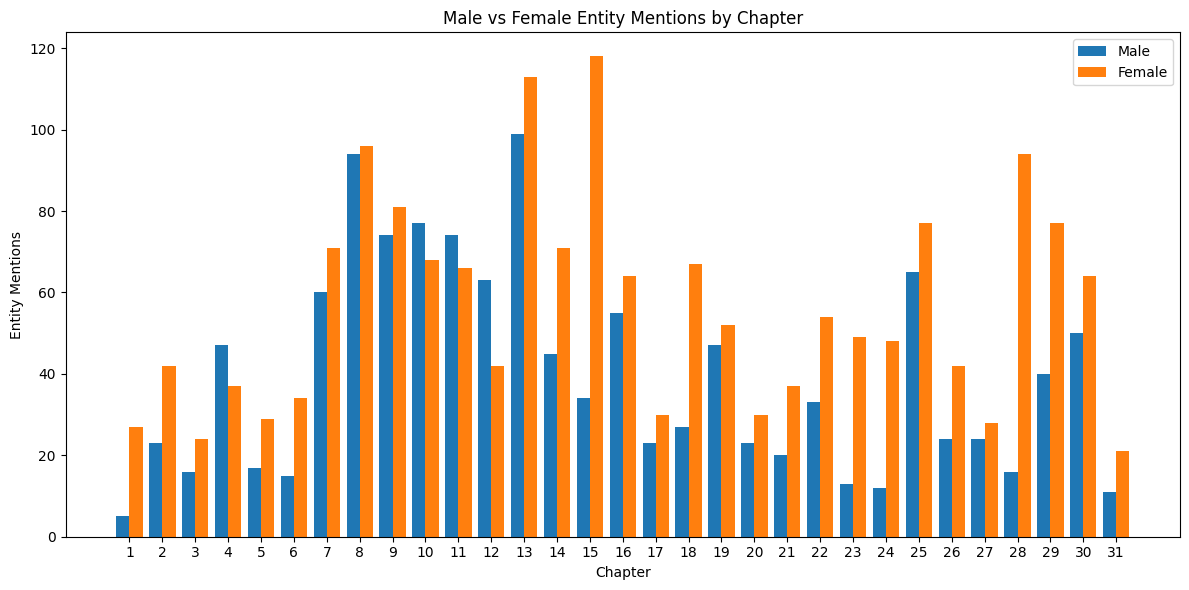

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Example dataframe columns:
# chapter | Male-entities | Female-entities

x = np.arange(len(df["chapter"]))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width/2,
    df["Male-entities"],
    width,
    label="Male"
)

ax.bar(
    x + width/2,
    df["Female-entities"],
    width,
    label="Female"
)

ax.set_xlabel("Chapter")
ax.set_ylabel("Entity Mentions")
ax.set_title("Male vs Female Entity Mentions by Chapter")

ax.set_xticks(x)
ax.set_xticklabels(df["chapter"])

ax.legend()

plt.tight_layout()
plt.show()

In [38]:
pronoun_groups = {
    "male-pronouns": ["he", "him", "his"],
    "female-pronouns": ["she", "her", "hers"]
}

In [60]:
pronouns_df = count_entities_by_chapter('northanger_abbey_chapters/', pronoun_groups)
pronouns_df

,chapter,male-pronouns,female-pronouns
0,1,6,100
1,2,4,99
2,3,29,24
3,4,7,41
4,5,14,33
5,6,8,17
6,7,61,58
7,8,69,103
8,9,74,119
9,10,63,107


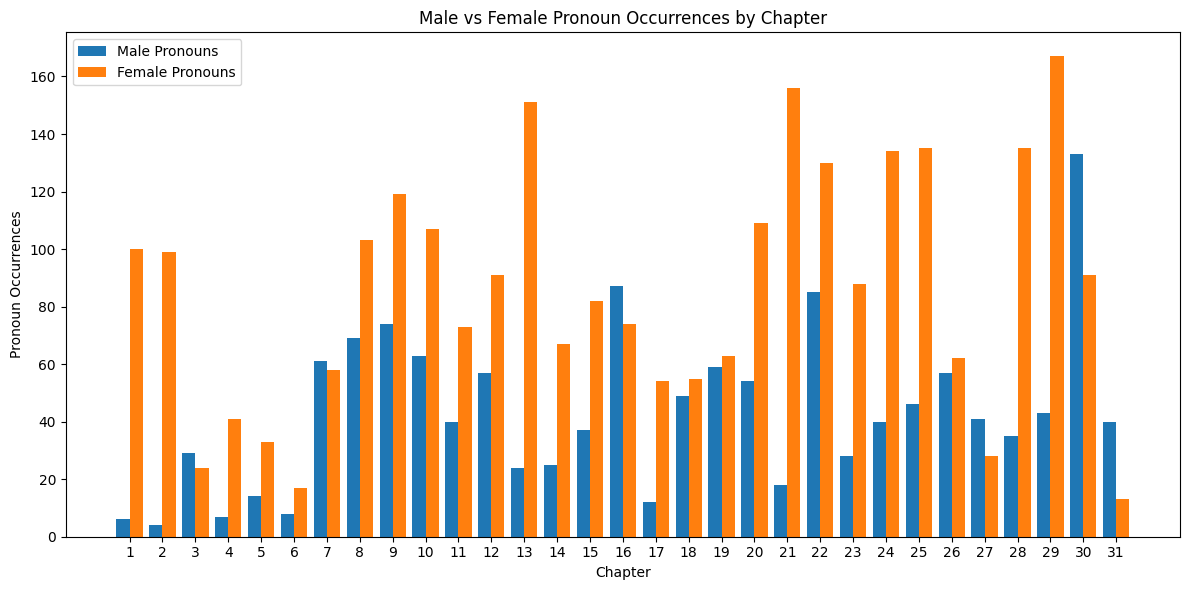

In [40]:
# Example dataframe columns:
# chapter | Male-entities | Female-entities

x = np.arange(len(df["chapter"]))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width/2,
    pronouns_df["male-pronouns"],
    width,
    label="Male Pronouns"
)

ax.bar(
    x + width/2,
    pronouns_df["female-pronouns"],
    width,
    label="Female Pronouns"
)

ax.set_xlabel("Chapter")
ax.set_ylabel("Pronoun Occurrences")
ax.set_title("Male vs Female Pronoun Occurrences by Chapter")

ax.set_xticks(x)
ax.set_xticklabels(df["chapter"])

ax.legend()

plt.tight_layout()
plt.show()

In [41]:
import nltk

In [42]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [43]:
sid = SentimentIntensityAnalyzer()

In [44]:
from textblob import TextBlob

In [50]:
from pathlib import Path
import re
import pandas as pd
from textblob import TextBlob

def analyze_chapter_sentiment(chapter_dir):
    """
    Run TextBlob sentiment analysis on chapter files.

    Returns a dataframe with:
    - chapter number
    - polarity
    - subjectivity
    - assessments
    """

    chapter_dir = Path(chapter_dir)

    rows = []

    chapter_files = sorted(chapter_dir.glob("*.txt"))

    for filepath in chapter_files:

        # Extract chapter number from filename
        match = re.search(r"(\d+)", filepath.stem)

        if not match:
            continue

        chapter_num = int(match.group(1))

        # Read text
        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read()

        # Create blob
        blob = TextBlob(text)

        # Standard sentiment
        polarity = blob.sentiment.polarity
        subjectivity = blob.sentiment.subjectivity

        # Fine-grained assessments
        assessments = blob.sentiment_assessments.assessments

        positive_count = sum(1 for a in assessments if a[1] > 0)
        negative_count = sum(1 for a in assessments if a[1] < 0)

        rows.append({
            "chapter": chapter_num,
            "polarity": polarity,
            "subjectivity": subjectivity,
            "assessments": assessments,
            "positive_count": positive_count,
            "negative_count": negative_count
        })

    df = pd.DataFrame(rows)

    return df.sort_values("chapter").reset_index(drop=True)



In [54]:
sentiment_df = analyze_chapter_sentiment('northanger_abbey_chapters/')
sentiment_df

,chapter,polarity,subjectivity,assessments,positive_count,negative_count
0,1,0.155378,0.517938,"[([own], 0.6, 1.0, None), ([equally], 0.0, 0.2...",79,40
1,2,0.162966,0.550381,"[([personal], 0.0, 0.3, None), ([mental], -0.1...",103,42
2,3,0.153704,0.503312,"[([regular], 0.0, 0.07692307692307693, None), ...",92,39
3,4,0.172069,0.473140,"[([more], 0.5, 0.5, None), ([usual], -0.25, 0....",70,30
4,5,0.146714,0.535585,"[([much], 0.2, 0.2, None), ([certainly], 0.214...",53,27
5,6,0.173740,0.528157,"[([following], 0.0, 0.1, None), ([very, warm],...",90,40
6,7,0.162854,0.536163,"[([half], -0.16666666666666666, 0.166666666666...",132,61
7,8,0.137147,0.505825,"[([upper], 0.0, 0.0, None), ([very, good], 0.9...",119,51
8,9,0.181028,0.543698,"[([first], 0.25, 0.3333333333333333, None), ([...",153,69
9,10,0.140131,0.534511,"[([latter], 0.0, 0.0, None), ([utter], 0.0, 1....",157,86


In [55]:
sentiment_df["sentiment_balance"] = sentiment_df['positive_count'] - sentiment_df['negative_count']

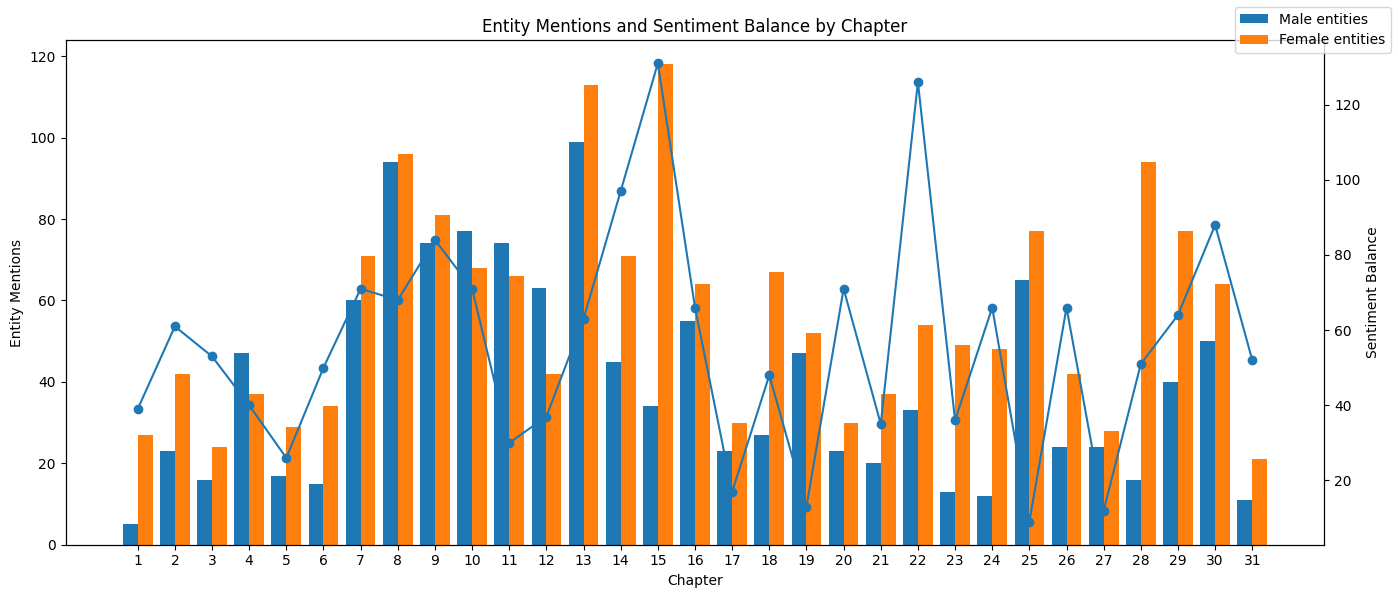

In [56]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(df))
width = 0.4

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bars
ax1.bar(
    x - width/2,
    df["Male-entities"],
    width,
    label="Male entities"
)

ax1.bar(
    x + width/2,
    df["Female-entities"],
    width,
    label="Female entities"
)

ax1.set_xlabel("Chapter")
ax1.set_ylabel("Entity Mentions")
ax1.set_xticks(x)
ax1.set_xticklabels(df["chapter"])

# Second axis
ax2 = ax1.twinx()

ax2.plot(
    x,
    sentiment_df["sentiment_balance"],
    marker="o"
)

ax2.set_ylabel("Sentiment Balance")

fig.legend(loc="upper right")

plt.title("Entity Mentions and Sentiment Balance by Chapter")

plt.tight_layout()
plt.show()

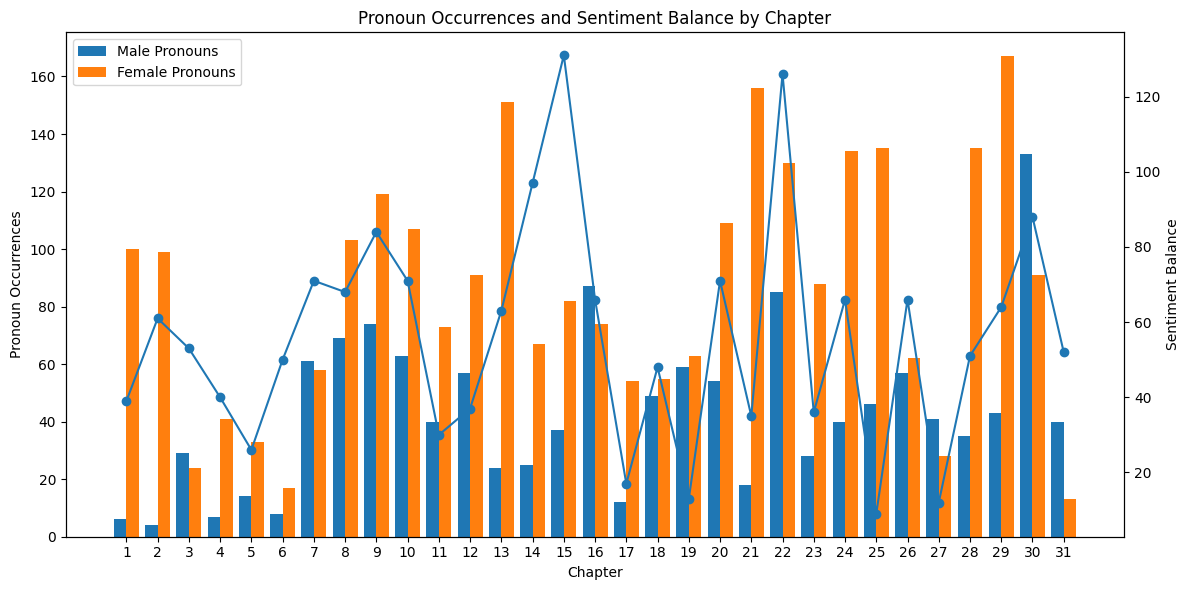

In [59]:
# Example dataframe columns:
# chapter | Male-entities | Female-entities

x = np.arange(len(df["chapter"]))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width/2,
    pronouns_df["male-pronouns"],
    width,
    label="Male Pronouns"
)

ax.bar(
    x + width/2,
    pronouns_df["female-pronouns"],
    width,
    label="Female Pronouns"
)

ax.set_xlabel("Chapter")
ax.set_ylabel("Pronoun Occurrences")

ax.set_xticks(x)
ax.set_xticklabels(df["chapter"])

ax.legend()

# Second axis
ax2 = ax.twinx()

ax2.plot(
    x,
    sentiment_df["sentiment_balance"],
    marker="o"
)

ax2.set_ylabel("Sentiment Balance")

plt.title("Pronoun Occurrences and Sentiment Balance by Chapter")

plt.tight_layout()
plt.show()